# Construcción del modelo de clasificación de vinos
Dataset **Wine** de scikit-learn · Pipeline (StandardScaler + SVC lineal) · Resultado: `n_vinos.pkl`

In [1]:
from datetime import datetime
from zoneinfo import ZoneInfo
print('Ejecutado:', datetime.now(ZoneInfo('America/Monterrey')).strftime('%d/%m/%Y %H:%M:%S'))

Ejecutado: 24/09/2026 17:58:18


## Paso 1. Importar las librerías

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Paso 2. Cargar el dataset

In [3]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Paso 3. Asignar nombres a las clases

In [4]:
nombres = {0: 'Cabernet', 1: 'Merlot', 2: 'Pinot Noir'}
df['tipo_vino'] = df['target'].map(nombres)
df[['target', 'tipo_vino']].head()

,target,tipo_vino
0,0,Cabernet
1,0,Cabernet
2,0,Cabernet
3,0,Cabernet
4,0,Cabernet


## Paso 4. Exploración inicial

In [5]:
print('Dimensiones:', df.shape)
print('Cantidad de variables:', df.shape[1])
print('\nTipos de datos:')
print(df.dtypes)

Dimensiones: (178, 15)
Cantidad de variables: 15

Tipos de datos:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
tipo_vino                        object
dtype: object


In [6]:
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
tipo_vino                       0
dtype: int64


In [7]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


tipo_vino
Merlot        71
Cabernet      59
Pinot Noir    48
Name: count, dtype: int64


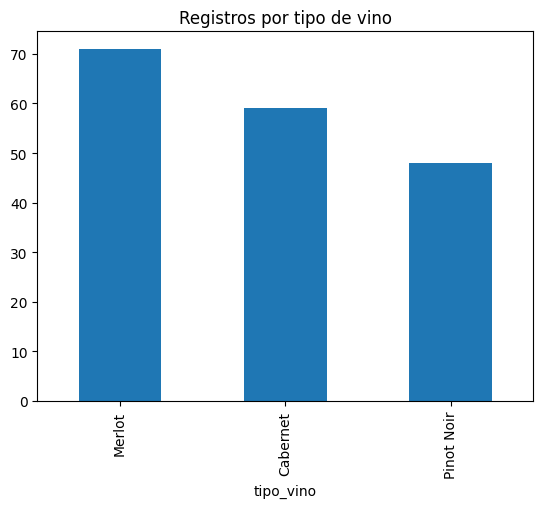

In [8]:
print(df['tipo_vino'].value_counts())
df['tipo_vino'].value_counts().plot(kind='bar', title='Registros por tipo de vino')
plt.show()

**¿Existen valores faltantes?** No, todas las columnas tienen 0 valores nulos.

**¿Las tres clases contienen la misma cantidad de registros?** No. Merlot tiene 71, Cabernet 59 y Pinot Noir 48. Están algo desbalanceadas, por eso conviene estratificar.

**¿Se observa alguna diferencia importante entre las escalas?** Sí. `proline` tiene valores de cientos a más de 1,600, mientras que variables como `hue` o `nonflavanoid_phenols` están por debajo de 2. Por eso hay que escalar los datos antes del SVM.

## Paso 5. Definir las variables del modelo

In [9]:
caracteristicas = ['alcohol', 'malic_acid', 'color_intensity', 'proline']
X = df[caracteristicas]
y = df['tipo_vino']
print('X:', X.shape)
print('y:', y.shape)

X: (178, 4)
y: (178,)


## Paso 6. Conjuntos de entrenamiento y prueba

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)

X_train: (142, 4) | X_test: (36, 4)
y_train: (142,) | y_test: (36,)


**¿Por qué no se usa el 100 % para entrenar?** Porque necesitamos datos que el modelo nunca vio para evaluar si realmente generaliza. Si se evalúa con los mismos datos de entrenamiento, el resultado sale engañosamente alto.

**¿Qué función cumple la estratificación?** Mantiene la misma proporción de cada tipo de vino en entrenamiento y en prueba, para que ninguna clase quede subrepresentada en alguno de los dos conjuntos.

## Paso 7. Crear el Pipeline

In [11]:
modelo = Pipeline([
    ('escalador', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])
modelo

Pipeline(steps=[('escalador', StandardScaler()), ('svm', SVC(kernel='linear'))])

## Paso 8. Entrenar el modelo

In [12]:
modelo.fit(X_train, y_train)
print('Clases aprendidas:', list(modelo.classes_))

Clases aprendidas: ['Cabernet', 'Merlot', 'Pinot Noir']


**¿Por qué conviene incluir el escalamiento y el modelo en el mismo Pipeline?** Porque el escalador aprende sus medias y desviaciones solo con los datos de entrenamiento (sin fuga de datos) y luego se aplica automáticamente igual a los datos de prueba y a cualquier dato nuevo. Además, todo se guarda y se usa como un solo objeto.

## Paso 9. Realizar las predicciones

In [13]:
y_pred = modelo.predict(X_test)
comparacion = pd.DataFrame({'Real': y_test.values, 'Predicho': y_pred})
comparacion

,Real,Predicho
0,Cabernet,Cabernet
1,Pinot Noir,Merlot
2,Cabernet,Cabernet
3,Merlot,Pinot Noir
4,Merlot,Merlot
5,Cabernet,Cabernet
6,Cabernet,Cabernet
7,Merlot,Merlot
8,Merlot,Merlot
9,Pinot Noir,Pinot Noir


## Paso 10. Evaluar el modelo

In [14]:
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.9167

              precision    recall  f1-score   support

    Cabernet       1.00      1.00      1.00        12
      Merlot       0.87      0.93      0.90        14
  Pinot Noir       0.89      0.80      0.84        10

    accuracy                           0.92        36
   macro avg       0.92      0.91      0.91        36
weighted avg       0.92      0.92      0.92        36



**Análisis:** el modelo obtuvo un accuracy de 0.92 (33 de 36 vinos bien clasificados).

- **Cabernet:** precision, recall y F1 de 1.00, lo clasifica perfecto.
- **Merlot:** precision 0.87, recall 0.93, F1 0.90. Encuentra casi todos los Merlot, pero a veces etiqueta como Merlot vinos que no lo son.
- **Pinot Noir:** precision 0.89, recall 0.80, F1 0.84. Es la clase más difícil: se le escapan algunos Pinot Noir.

## Paso 11. Matriz de confusión

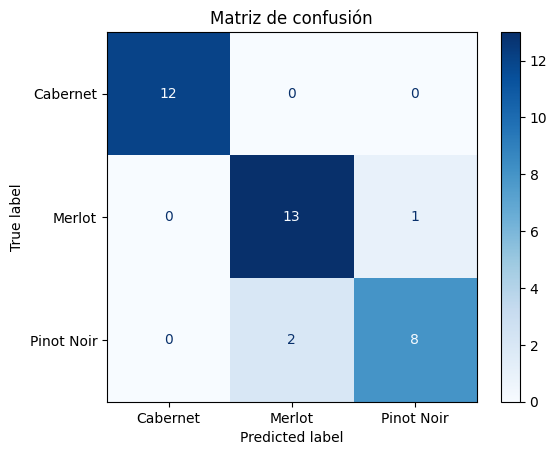

In [15]:
etiquetas = ['Cabernet', 'Merlot', 'Pinot Noir']
cm = confusion_matrix(y_test, y_pred, labels=etiquetas)
ConfusionMatrixDisplay(cm, display_labels=etiquetas).plot(cmap='Blues')
plt.title('Matriz de confusión')
plt.show()

**Correctas:** la diagonal (12 Cabernet, 13 Merlot, 8 Pinot Noir = 33 aciertos).

**Errores:** 3 en total, fuera de la diagonal.

**Mayor confusión:** entre Merlot y Pinot Noir, que se confunden entre sí; Cabernet no tiene errores.

## Paso 12. Probar un nuevo vino

In [16]:
nuevo_vino = pd.DataFrame([[13.5, 1.8, 5.2, 1000]], columns=caracteristicas)
prediccion_antes = modelo.predict(nuevo_vino)
print('Tipo de vino predicho:', prediccion_antes[0])

Tipo de vino predicho: Cabernet


## Paso 13. Guardar el modelo

In [17]:
joblib.dump(modelo, 'n_vinos.pkl')

if os.path.exists('n_vinos.pkl'):
    print('Archivo generado correctamente:', os.path.abspath('n_vinos.pkl'))
    print('Tamaño:', os.path.getsize('n_vinos.pkl'), 'bytes')

Archivo generado correctamente: /content/modelo_wine.pkl
Tamaño: 4725 bytes


## Paso 14. Recuperar el modelo

In [18]:
modelo_recuperado = joblib.load('n_vinos.pkl')
prediccion_despues = modelo_recuperado.predict(nuevo_vino)

print('Predicción antes de guardar:', prediccion_antes[0])
print('Predicción del modelo recuperado:', prediccion_despues[0])
print('¿Son iguales?', prediccion_antes[0] == prediccion_despues[0])

Predicción antes de guardar: Cabernet
Predicción del modelo recuperado: Cabernet
¿Son iguales? True


In [19]:
# Descargar el .pkl a tu computadora
from google.colab import files
files.download('n_vinos.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Reflexión final

**Entrenar un modelo** significa darle datos etiquetados para que aprenda patrones: el escalador calcula medias y desviaciones y el SVM encuentra las fronteras que separan las clases. Requiere datos, tiempo y cómputo, y se hace una vez.

**Utilizar un modelo previamente entrenado** significa cargar ese conocimiento ya aprendido (con `joblib.load`) y aplicarlo a datos nuevos con `predict()`, sin volver a entrenar. Es rápido y da exactamente los mismos resultados, como se comprobó en el paso 14.

**Flujo:** Datos (dataset Wine) → preparación (nombres de clases, selección de 4 características, división 80/20 estratificada) → Pipeline (StandardScaler + SVC lineal) → entrenamiento (`fit` con datos de entrenamiento) → evaluación (accuracy, precision, recall, F1, matriz de confusión) → Joblib (`dump`) → `n_vinos.pkl`.